# Final Group Project (Applied ML & Statistics)

This notebook is organized exactly according to the course **Practical Exam Project** workflow:

1. **Project Title & Problem Statement**
2. **Dataset (DOI) + Description**
3. **Preprocessing**
4. **Noise Injection & Cleaning**
5. **Statistical Analysis (stats + 3 plots)**
6. **Supervised Learning (regression)**
7. **Unsupervised Learning (clustering + PCA)**
8. **Discussion / What we learned**

> Goal: Use global mineral production data (2000–2020) to study whether the energy transition may create a *new* dependency: **critical minerals**.


## 1) Project Title & Problem Statement

**Title:** *From Oil to Ore: Measuring Fragility in Critical Mineral Supply Chains (2000–2020)*

**Research question:**  
**Is the global energy transition replacing oil dependency with a more fragile dependence on critical minerals?**

We approach this by measuring:
- **Concentration** (few countries dominate supply?)
- **Volatility / shocks** (how sensitive is the system?)
- **Structural patterns** (do countries form distinct producer clusters?)


## 2) Dataset (DOI) + Files Used

**Primary computational dataset:** Zenodo “Global coal & metal mine production” (DOI).  
We use the **structured files** from the download:

- `facilities.gpkg` → contains `facility_id` and `country` (metadata / location)
- `minerals.csv` → contains `facility_id`, `year`, `material`, `value_tonnes` (production)




## 3) Preprocessing: Build a clean master dataset

We first extract a country lookup from the GeoPackage, then merge it with production data and aggregate mine-level rows into **country–year–material** totals.

In [2]:
# === Extract country lookup from facilities.gpkg ===
import geopandas as gpd
import pandas as pd

# Load geopackage
gdf = gpd.read_file("/content/facilities.gpkg")

# Check columns
print("Columns in facilities.gpkg:", list(gdf.columns))

# Keep only what you need
facilities = gdf[['facility_id', 'country']]

# Save as CSV
facilities.to_csv("facilities_country.csv", index=False)

print("facilities_country.csv created")


Columns in facilities.gpkg: ['facility_id', 'facility_name', 'facility_other_names', 'sub_site_name', 'sub_site_other_names', 'facility_type', 'primary_commodity', 'commodities_products', 'facility_equipment', 'production_start', 'production_end', 'activity_status', 'activity_status_year', 'surface_area_sq_km', 'concession_area_sq_km', 'country', 'GID_0', 'GID_1', 'GID_2', 'GID_3', 'GID_4', 'source_id', 'comment', 'geometry']
facilities_country.csv created


In [3]:
# === Merge production with country and create a basic master CSV ===
import pandas as pd

# Load the two core tables/files
minerals = pd.read_csv("/content/minerals.csv")
facilities = pd.read_csv("/content/facilities_country.csv")

# Keep only the columns we need for analysis (smaller = faster & clearer)
minerals = minerals[['facility_id', 'year', 'material', 'value_tonnes']]

# Merge production rows with country metadata using facility_id
df = minerals.merge(facilities, on='facility_id', how='left')

# Rename column
df = df.rename(columns={'value_tonnes': 'production_tonnes'})

# Keep final analysis columns only
df = df[['country', 'year', 'material', 'production_tonnes']]

# Save master dataset
df.to_csv("master_world_mining.csv", index=False)

print("master_world_mining.csv created")


master_world_mining.csv created


In [4]:
# === Aggregate mine-level production into country–year–material totals ===
import pandas as pd

minerals = pd.read_csv("/content/minerals.csv")
fac = pd.read_csv("/content/facilities_country.csv")

# Ensure unique facility_id
fac = fac.drop_duplicates(subset=["facility_id"])

# Merge
df = minerals.merge(fac, on="facility_id", how="left")

# Rename
df = df.rename(columns={"value_tonnes": "production_tonnes"})

# Aggregate to country-year-material (recommended)
# Why: multiple mines exist per country; for policy/supply-chain risk we care about national totals.
df = (df.groupby(["country","year","material"], as_index=False)
        ["production_tonnes"].sum())

df.to_csv("master_world_mining_agg.csv", index=False)
print("Saved: master_world_mining_agg.csv", df.shape)


Saved: master_world_mining_agg.csv (2587, 4)


In [5]:
# === Load the clean aggregated dataset ===
import pandas as pd
import numpy as np

df = pd.read_csv("/content/master_world_mining_agg.csv")  # your clean file
df.head()


,country,year,material,production_tonnes
0,Argentina,2001,O.Au,864864
1,Argentina,2002,O.Au,1297298
2,Argentina,2003,O.Au,1945946
3,Argentina,2004,O.Au,1945946
4,Argentina,2005,O.Au,10971946


## 4) Noise Injection & Cleaning

Real-world reporting is noisy. We simulate uncertainty using Gaussian noise and rare shock events, then apply outlier mitigation + smoothing. We compare **Original vs Noisy vs Cleaned**.

In [6]:
import numpy as np

# === Define a critical-minerals basket available in this dataset ===
critical_materials = ["O.Li","Con.Li","O.Ni","Con.Ni","Con.Ta","O.Mn","Con.MnO","Con.MnCO3"]
critical_materials = [m for m in critical_materials if m in df["material"].unique()]
critical_materials


['O.Li', 'Con.Li', 'O.Ni', 'Con.Ni', 'Con.Ta', 'O.Mn', 'Con.MnO', 'Con.MnCO3']

In [7]:
# === Inject noise: Gaussian reporting noise + rare shock outliers ===
np.random.seed(42)

df["production_noisy"] = df["production_tonnes"].astype(float)

mask_crit = df["material"].isin(critical_materials)

# More uncertainty for critical minerals (8%), less for others (3%)
df.loc[mask_crit, "production_noisy"] *= (1 + np.random.normal(0, 0.08, mask_crit.sum()))
df.loc[~mask_crit, "production_noisy"] *= (1 + np.random.normal(0, 0.03, (~mask_crit).sum()))

# Add rare shocks (1% of critical rows)
# This mimics disruption years (strikes, conflict, export bans, etc.).
crit_idx = df.index[mask_crit].to_numpy()
n_shocks = max(1, int(0.01 * len(crit_idx)))

shock_rows = np.random.choice(crit_idx, size=n_shocks, replace=False)
shock_factors = np.random.choice([0.3, 0.5, 1.8, 2.5], size=n_shocks)  # drops or spikes

df.loc[shock_rows, "production_noisy"] *= shock_factors
df["production_noisy"] = df["production_noisy"].clip(lower=0)


In [8]:
# === Denoise: clip outliers with an IQR rule (robust to skew) ===
def iqr_clip(s: pd.Series) -> pd.Series:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return s.clip(lower=max(lo, 0), upper=hi)

df["production_denoised"] = (
    df.groupby(["country","material"])["production_noisy"]
      .transform(iqr_clip)
)


In [9]:
# === Smooth: 3-year rolling mean to reduce short-term noise ===
df = df.sort_values("year")
df["production_smoothed"] = (
    df.groupby(["country","material"])["production_denoised"]
      .transform(lambda x: x.rolling(3, min_periods=1).mean())
)
# Safety clip to avoid any negative values after smoothing
df["production_smoothed"] = df["production_smoothed"].clip(lower=0)


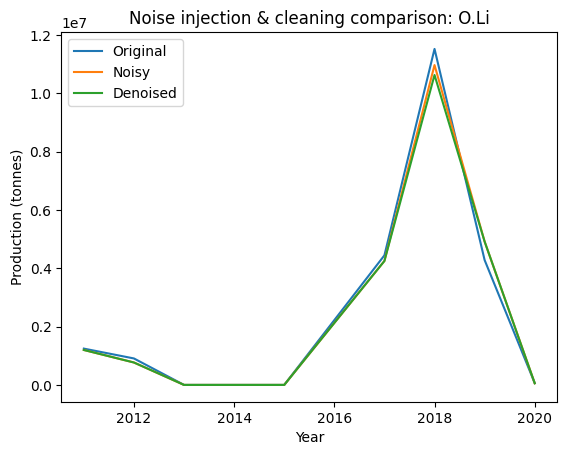

In [10]:
# === Plot comparison: Original vs Noisy vs Cleaned ===
import matplotlib.pyplot as plt

mat = "O.Li" if "O.Li" in df["material"].unique() else df["material"].unique()[0]

plot_df = (df[df["material"]==mat]
           .groupby("year", as_index=False)[["production_tonnes","production_noisy","production_denoised"]]
           .sum())

plt.figure()
plt.plot(plot_df["year"], plot_df["production_tonnes"], label="Original")
plt.plot(plot_df["year"], plot_df["production_noisy"], label="Noisy")
plt.plot(plot_df["year"], plot_df["production_denoised"], label="Denoised")
plt.title(f"Noise injection & cleaning comparison: {mat}")
plt.xlabel("Year")
plt.ylabel("Production (tonnes)")
plt.legend()
plt.show()


In [11]:
# === Save dataset after Step 4 (noise + cleaning) ===
df.to_csv("/content/dataset_step4_noise_cleaning.csv", index=False)
print("Saved: dataset_step4_noise_cleaning.csv")


Saved: dataset_step4_noise_cleaning.csv


## 5) Statistical Analysis

We compute descriptive statistics (mean, variance, skewness, correlation) and create at least **3 plots** to understand concentration and distribution.

In [12]:
# === Load cleaned dataset for statistics + plots (Step 5) ===
import pandas as pd

df = pd.read_csv("/content/dataset_step4_noise_cleaning.csv")

stats = df["production_smoothed"].describe()
stats


,production_smoothed
count,2.587000e+03
mean,3.897359e+07
std,1.169839e+08
min,0.000000e+00
25%,8.702528e+05
50%,5.069824e+06
75%,2.846445e+07
max,1.618965e+09


In [13]:
# === Compute skewness and kurtosis (shape of distribution) ===
skewness = df["production_smoothed"].skew()
kurtosis = df["production_smoothed"].kurt()

skewness, kurtosis


(np.float64(7.04153493778248), np.float64(64.54334701487399))

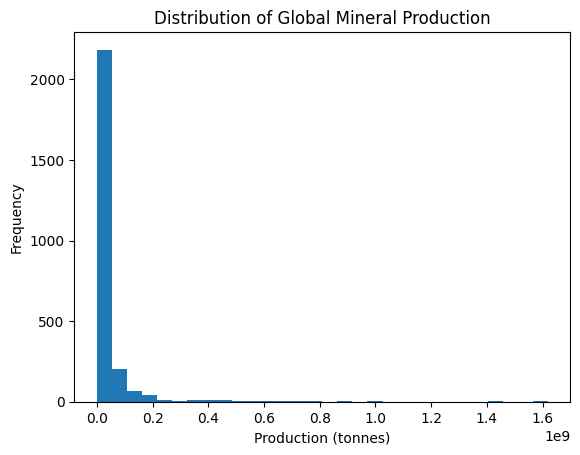

In [14]:
# === Plot 1: Global distribution (Histogram) ===
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["production_smoothed"], bins=30)
plt.xlabel("Production (tonnes)")
plt.ylabel("Frequency")
plt.title("Distribution of Global Mineral Production")
plt.show()


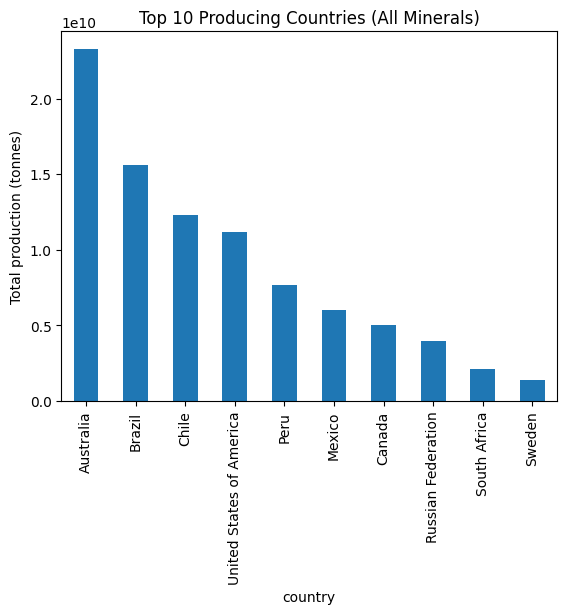

In [15]:
# === Plot 2: Top producing countries ===
top_countries = (
    df.groupby("country")["production_smoothed"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure()
top_countries.plot(kind="bar")
plt.ylabel("Total production (tonnes)")
plt.title("Top 10 Producing Countries (All Minerals)")
plt.show()


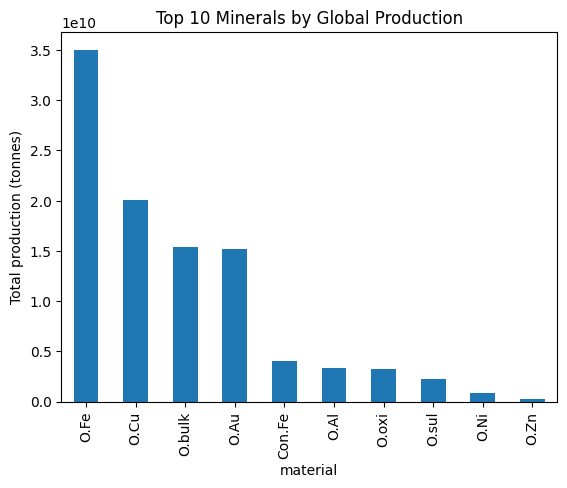

In [16]:
# === Plot 3: Top minerals by total production ===
top_minerals = (
    df.groupby("material")["production_smoothed"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure()
top_minerals.plot(kind="bar")
plt.ylabel("Total production (tonnes)")
plt.title("Top 10 Minerals by Global Production")
plt.show()


In [17]:
# === Optional: Concentration index (HHI) for country dominance ===
total = df["production_smoothed"].sum()

country_shares = (
    df.groupby("country")["production_smoothed"].sum() / total
)

HHI = (country_shares**2).sum()
HHI


np.float64(0.11934432559244007)

## 6) Supervised Learning (Regression)

We predict **next-year production** using lag features. Models: **Linear Regression** (baseline) and **Random Forest Regressor** (non-linear). Metrics: **RMSE** and **R²**.

In [18]:
# === Create supervised-learning target: predict next-year production ===
import pandas as pd
import numpy as np

df = pd.read_csv("/content/dataset_step4_noise_cleaning.csv")

# Use cleaned signal for learning
df = df.sort_values(["country","material","year"]).copy()

# Create next-year target
df["target_next_year"] = df.groupby(["country","material"])["production_smoothed"].shift(-1)

# Drop rows where next-year target doesn't exist (last year per group)
df = df.dropna(subset=["target_next_year"]).copy()

df[["country","material","year","production_smoothed","target_next_year"]].head()


,country,material,year,production_smoothed,target_next_year
61,Argentina,O.Au,2001,8.522708e+05,1.076378e+06
85,Argentina,O.Au,2002,1.076378e+06,1.411276e+06
166,Argentina,O.Au,2003,1.411276e+06,1.739498e+06
294,Argentina,O.Au,2004,1.739498e+06,5.038615e+06
412,Argentina,O.Au,2005,5.038615e+06,4.984389e+06


In [19]:
# === Feature engineering: lag features + growth rate ===
df["lag1"] = df.groupby(["country","material"])["production_smoothed"].shift(1)
df["lag2"] = df.groupby(["country","material"])["production_smoothed"].shift(2)

df["growth_rate"] = (df["production_smoothed"] - df["lag1"]) / (df["lag1"] + 1e-9)

# Drop rows where lags are missing (early years)
df = df.dropna(subset=["lag1","lag2","growth_rate"]).copy()

df[["production_smoothed","lag1","lag2","growth_rate","target_next_year"]].head()


,production_smoothed,lag1,lag2,growth_rate,target_next_year
166,1.411276e+06,1.076378e+06,8.522708e+05,0.311134,1.739498e+06
294,1.739498e+06,1.411276e+06,1.076378e+06,0.232571,5.038615e+06
412,5.038615e+06,1.739498e+06,1.411276e+06,1.896591,4.984389e+06
439,4.984389e+06,5.038615e+06,1.739498e+06,-0.010762,5.021976e+06
548,5.021976e+06,4.984389e+06,5.038615e+06,0.007541,1.924094e+06


In [20]:
# === One-hot encode categorical variables + train/test split ===
from sklearn.model_selection import train_test_split

X = df[["country","material","year","production_smoothed","lag1","lag2","growth_rate"]]
y = df["target_next_year"]

X = pd.get_dummies(X, columns=["country","material"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((1524, 93), (382, 93))

In [21]:
# === Model A: Linear Regression baseline ===
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)


In [22]:
# === Model B: Random Forest Regressor ===
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)


In [23]:
# === Evaluation: RMSE and R² ===
from sklearn.metrics import mean_squared_error, r2_score

def eval_reg(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:,.0f} | R2: {r2:.3f}")

eval_reg(y_test, pred_lr, "Linear Regression")
eval_reg(y_test, pred_rf, "Random Forest")


Linear Regression -> RMSE: 10,920,986 | R2: 0.985
Random Forest -> RMSE: 11,309,729 | R2: 0.984


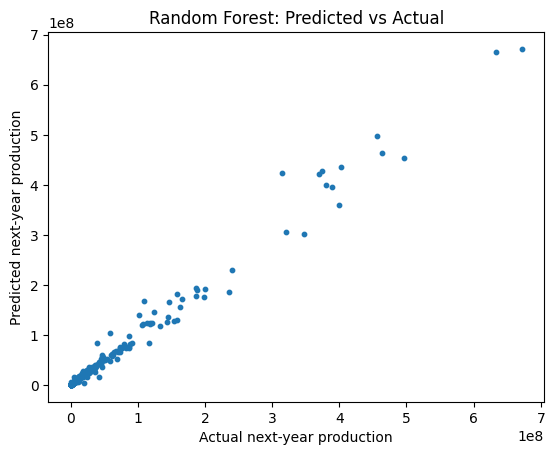

In [24]:
# === Visualization: Predicted vs Actual ===
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, pred_rf, s=10)
plt.xlabel("Actual next-year production")
plt.ylabel("Predicted next-year production")
plt.title("Random Forest: Predicted vs Actual")
plt.show()


In [26]:
# === Save predictions for reporting ===
results = pd.DataFrame({
    "actual": y_test.values,
    "pred_lr": pred_lr,
    "pred_rf": pred_rf
})

results.to_csv("/content/step6_predictions.csv", index=False)
print("Saved: step6_predictions.csv")


Saved: step6_predictions.csv


## 7) Unsupervised Learning (Clustering + PCA)

We cluster countries based on their mineral production profiles and visualize the structure using **PCA**. This reveals producer archetypes and potential dependency risks.

In [27]:
# === Build country × mineral matrix for clustering ===
import pandas as pd

df = pd.read_csv("/content/dataset_step4_noise_cleaning.csv")

# Country–Mineral production matrix
country_mineral = (
    df.groupby(["country", "material"])["production_smoothed"]
      .sum()
      .reset_index()
      .pivot(index="country", columns="material", values="production_smoothed")
      .fillna(0)
)

country_mineral.shape


(53, 44)

In [28]:
# === Standardize features (important for K-Means) ===
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(country_mineral)


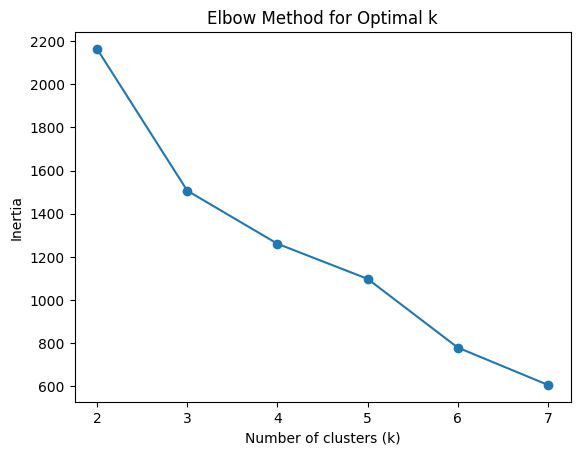

In [29]:
# === Choose k using Elbow Method ===
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure()
plt.plot(range(2, 8), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()


In [30]:
# === Fit final K-Means model and assign cluster labels ===
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

country_clusters = country_mineral.copy()
country_clusters["cluster"] = clusters

country_clusters[["cluster"]].value_counts()


,count
cluster,
0,50
1,2
2,1


In [31]:
# === Cluster interpretation: total production profile by cluster ===
cluster_summary = (
    country_clusters
    .groupby("cluster")
    .sum()
)

cluster_summary


material,Con.Cr,Con.Cu,Con.Fe,Con.Li,Con.MnCO3,Con.MnO,Con.Mo,Con.Ni,Con.Pb,Con.Ta,...,O.bulk,O.dig,O.flu,O.leu,O.nep,O.oxi,O.pgm,O.sul,Oth.cuce,Oth.sif
cluster,,,,,,,,,,,,,,,,,,,,,
0,2.184522e+07,5.368202e+07,3.669917e+09,0.000000e+00,8.001769e+06,4.242882e+06,976.819718,2.610209e+05,5.430526e+06,0.000000,...,6.095643e+09,1.339424e+07,4.979168e+06,183947.168032,9.195105e+07,6.580582e+08,1.669699e+08,1.759897e+09,0.000000,2.991854e+07
1,0.000000e+00,3.668237e+07,1.016073e+08,0.000000e+00,0.000000e+00,0.000000e+00,517199.145422,0.000000e+00,5.945045e+05,0.000000,...,7.431945e+09,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,2.621900e+09,0.000000e+00,4.838911e+08,0.000000,0.000000e+00
2,0.000000e+00,7.008801e+06,2.243022e+08,1.580784e+06,0.000000e+00,0.000000e+00,0.000000,9.183698e+07,1.438802e+05,1063.905643,...,1.837201e+09,0.000000e+00,0.000000e+00,332244.481363,0.000000e+00,6.138508e+06,0.000000e+00,5.763224e+04,3334.406648,0.000000e+00


In [32]:
# === PCA: reduce high-dimensional mineral space to 2D for visualization ===
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = clusters
pca_df["country"] = country_mineral.index


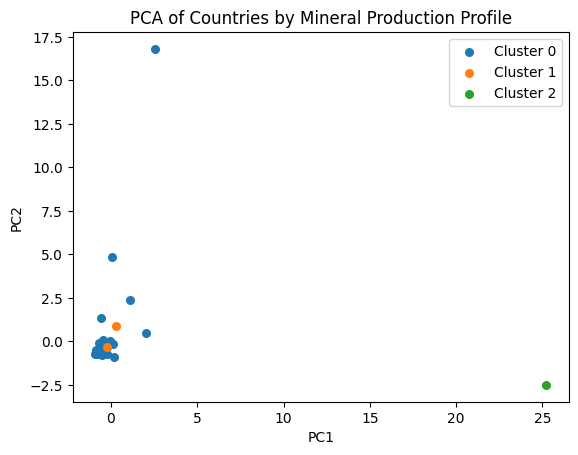

In [33]:
# === PCA scatter plot colored by cluster ===
plt.figure()
for c in sorted(pca_df["cluster"].unique()):
    subset = pca_df[pca_df["cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {c}", s=30)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Countries by Mineral Production Profile")
plt.legend()
plt.show()


In [34]:
# === Save clustering output for reporting ===
pca_df.to_csv("/content/step7_country_clusters.csv", index=False)
print("Saved: step7_country_clusters.csv")


Saved: step7_country_clusters.csv


## 8) Discussion (What we got at the end)

**Key takeaway:** Mineral production is strongly **concentrated** and **structurally imbalanced**.  
- Many countries are low/moderate producers.
- A small number of countries form dominant supply hubs (outliers).
- Supervised learning shows production is persistent year-to-year (short-term stability), but the structure is still fragile because dominance does not diversify quickly.

**Answer to the research question (data-driven):**  
Dependency does not disappear. It likely **shifts** from oil to a concentrated set of critical minerals.
